In [2]:
# SETUP - Mount Google Drive and Set Paths

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

train_dir = '/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/train'
test_dir  = '/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/test'

print("Train directory:", train_dir)
print("Test directory: ", test_dir)
print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train directory: /content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/train
Test directory:  /content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/FruitinAmazon/test
Setup complete.


Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total number of classes: 6


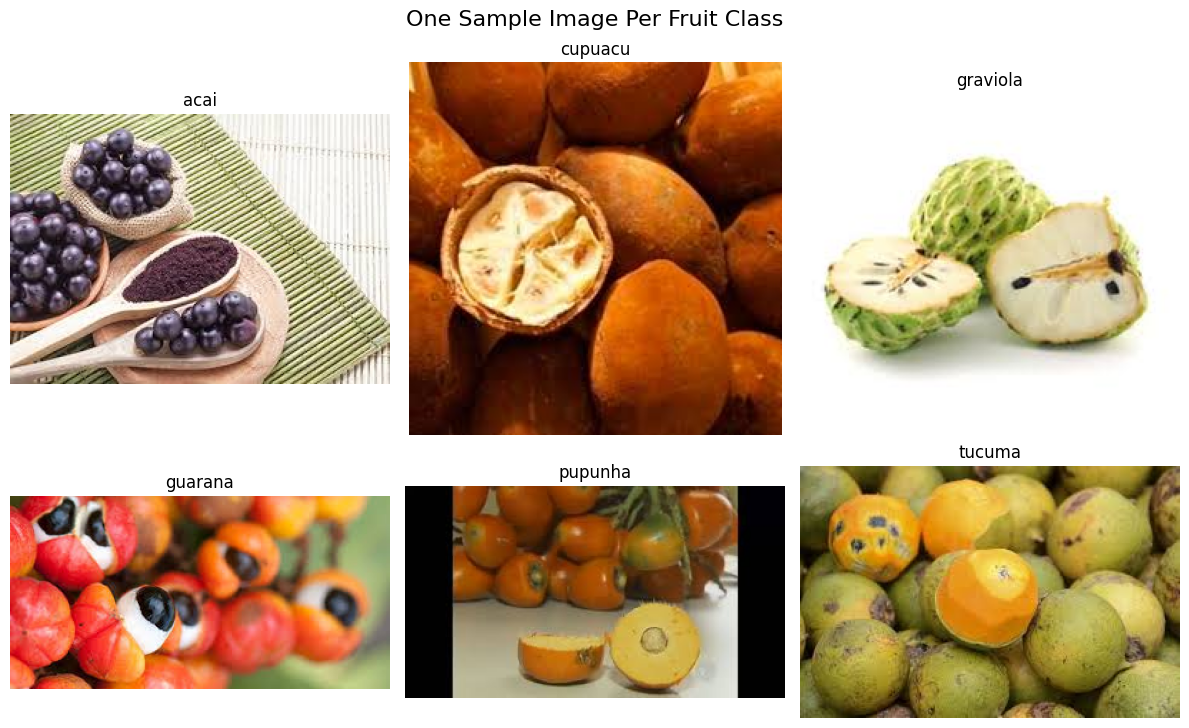

In [3]:
# TASK 1 - PART 1 - Data Understanding and Visualization

# The following code loads one random image from each fruit class
# in the training directory and displays them in a grid format.
# Each subdirectory in the train folder represents one fruit class.

import random

# Get list of all class directories from the train folder
class_names = sorted(os.listdir(train_dir))
print("Classes found:", class_names)
print("Total number of classes:", len(class_names))

# Calculate grid size - 2 rows, remaining columns
num_classes = len(class_names)
num_cols    = (num_classes + 1) // 2   # split evenly into 2 rows
num_rows    = 2

# Create the figure for displaying images
plt.figure(figsize=(num_cols * 4, num_rows * 4))

for i, class_name in enumerate(class_names):

    # Get full path of the class folder
    class_path = os.path.join(train_dir, class_name)

    # Get all image files in this class folder
    image_files = os.listdir(class_path)

    # Select one image randomly from the class
    random_image = random.choice(image_files)

    # Build full path to that image
    image_path = os.path.join(class_path, random_image)

    # Open and display the image
    img = Image.open(image_path)

    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.suptitle("One Sample Image Per Fruit Class", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# TASK 1 - PART 2 - Check for Corrupted Images

# The following code iterates through every image in the train
# directory and attempts to open each one using PIL.
# If an image raises an IOError or SyntaxError it is considered
# corrupted, removed from the directory and logged.

corrupted_images = []

# Iterate through each class folder in the train directory
for class_name in os.listdir(train_dir):

    # Build full path to the class folder
    class_path = os.path.join(train_dir, class_name)

    # Skip if not a directory
    if not os.path.isdir(class_path):
        continue

    # Iterate through each image in the class folder
    for image_name in os.listdir(class_path):

        # Build full path to the image
        image_path = os.path.join(class_path, image_name)

        try:
            # Attempt to open the image
            # verify() checks if the image is valid without
            # fully loading it into memory
            with Image.open(image_path) as img:
                img.verify()

        except (IOError, SyntaxError):
            # Image is corrupted - remove it and log it
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Print final summary
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


In [5]:
# TASK 2 - Loading and Preprocessing Image Data

# The image_dataset_from_directory function loads images
# directly from the directory structure where each subdirectory
# represents a class label.
# Images are resized, batched and normalized for model training.
# The dataset is split into 80% training and 20% validation.

# Define image dimensions and batch size
img_height       = 128
img_width        = 128
batch_size       = 32
validation_split = 0.2

# -----------------------------------------------

# Create a normalization layer
# Pixel values originally range from 0 to 255
# Dividing by 255 scales them to range 0 to 1
rescale = tf.keras.layers.Rescaling(1./255)

# -----------------------------------------------

# Load training dataset first WITHOUT map
# to extract class names before they are lost
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Save class names BEFORE applying map
class_names = train_ds_raw.class_names
num_classes  = len(class_names)

# Now apply normalization to training dataset
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# -----------------------------------------------

# Load validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# -----------------------------------------------

# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# Apply normalization to test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# -----------------------------------------------

print("Class names:", class_names)
print("Number of classes:", num_classes)
print("Training dataset loaded successfully.")
print("Validation dataset loaded successfully.")
print("Test dataset loaded successfully.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Training dataset loaded successfully.
Validation dataset loaded successfully.
Test dataset loaded successfully.


In [6]:
# TASK 3 - Build the CNN Model

# The CNN model consists of two convolutional blocks
# followed by a fully connected network.
# Each convolutional block contains a Conv2D layer
# with ReLU activation followed by a MaxPooling layer.
# The fully connected network consists of two dense layers
# and a final output layer with softmax activation.

from tensorflow.keras import layers, models

model = models.Sequential([

    # Convolutional Block 1
    # 32 filters of size 3x3 detect basic features
    # like edges and corners in the input images
    # padding=same keeps the output the same size as input
    # ReLU activation introduces non-linearity
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=(1, 1),
        activation='relu',
        input_shape=(img_height, img_width, 3)
    ),

    # Max pooling reduces spatial dimensions by half
    # 2x2 window with stride 2 selects the maximum value
    # in each 2x2 region
    layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    # Convolutional Block 2
    # 32 filters of size 3x3 detect more complex features
    # by building on the features from block 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        strides=(1, 1),
        activation='relu'
    ),

    # Second max pooling layer further reduces spatial dimensions
    layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    # Flatten Layer
    # Converts the 3D feature maps into a 1D vector
    # so it can be passed into the dense layers
    layers.Flatten(),

    # Fully Connected Network
    # Hidden layer 1 with 64 neurons and ReLU activation
    layers.Dense(64, activation='relu'),

    # Hidden layer 2 with 128 neurons and ReLU activation
    layers.Dense(128, activation='relu'),

    # Output Layer
    # One neuron per class with softmax activation
    # Softmax converts raw scores into probabilities
    # that sum to 1 across all classes
    layers.Dense(num_classes, activation='softmax')
])

# Print model summary to verify architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Model compiled successfully.
Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.2106 - loss: 2.0270
Epoch 1: val_loss improved from None to 1.76238, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.1944 - loss: 2.1144 - val_accuracy: 0.0000e+00 - val_loss: 1.7624
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.2095 - loss: 1.7244
Epoch 2: val_loss improved from 1.76238 to 1.60359, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 543ms/step - accuracy: 0.2222 - loss: 1.6921 - val_accuracy: 0.1667 - val_loss: 1.6036
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.2888 - loss: 1.5830
Epoch 3: val_loss did not improve from 1.60359
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.3194 - loss: 1.5534 - val_accuracy: 0.2222 - val_loss: 1.6243
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.3831 - loss: 1.3751
Epoch 4: val_loss improved from 1.60359 to 1.48107, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 584ms/step - accuracy: 0.4306 - loss: 1.3456 - val_accuracy: 0.3333 - val_loss: 1.4811
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.5388 - loss: 1.1193
Epoch 5: val_loss improved from 1.48107 to 1.09617, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.5694 - loss: 1.1309 - val_accuracy: 0.6667 - val_loss: 1.0962
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7297 - loss: 0.8688
Epoch 6: val_loss improved from 1.09617 to 1.00777, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.8472 - loss: 0.7227 - val_accuracy: 0.6667 - val_loss: 0.8532
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9097 - loss: 0.5420
Epoch 8: val_loss improved from 0.85324 to 0.56695, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 853ms/step - accuracy: 0.9167 - loss: 0.5156 - val_accuracy: 0.8889 - val_loss: 0.5670
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9317 - loss: 0.3554
Epoch 9: val_loss did not improve from 0.56695
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.8889 - loss: 0.4086 - val_accuracy: 0.8889 - val_loss: 0.6315
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9705 - loss: 0.2921
Epoch 10: val_loss did not improve from 0.56695
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.9583 - loss: 0.3028 - val_accuracy: 0.5000 - val_loss: 0.8643
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9144 - loss: 0.2671
Epoch 11: val_loss did not improve from 0.56695
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.9306 - loss: 0.2371 - val_accuracy: 0.8889 - val_loss: 0.5866
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324


Epoch 12: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.9861 - loss: 0.1306 - val_accuracy: 0.8889 - val_loss: 0.4438
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9705 - loss: 0.1462
Epoch 13: val_loss did not improve from 0.44377
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.9583 - loss: 0.1613 - val_accuracy: 0.8889 - val_loss: 0.4729
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 1.0000 - loss: 0.0605
Epoch 14: val_loss did not improve from 0.44377
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 738ms/step - accuracy: 1.0000 - loss: 0.0586 - val_accuracy: 0.7778 - val_loss: 0.6301
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9902 - loss: 0.0497
Epoch 15: val_loss improved from 0.44377 to 0.37770, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 15: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 853ms/step - accuracy: 0.9861 - loss: 0.0609 - val_accuracy: 0.8889 - val_loss: 0.3777
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 1.0000 - loss: 0.0378
Epoch 16: val_loss improved from 0.37770 to 0.20278, saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5



Epoch 16: finished saving model to /content/drive/MyDrive/AI and Machine Learning/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - accuracy: 1.0000 - loss: 0.0338 - val_accuracy: 0.9444 - val_loss: 0.2028
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9902 - loss: 0.0692
Epoch 17: val_loss did not improve from 0.20278
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 0.9861 - loss: 0.0755 - val_accuracy: 0.8889 - val_loss: 0.2126
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 1.0000 - loss: 0.0224
Epoch 18: val_loss did not improve from 0.20278
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 508ms/step - accuracy: 1.0000 - loss: 0.0206 - val_accuracy: 0.8333 - val_loss: 0.4761
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 1.0000 - loss: 0.0193
Epoch 19: val_loss did not improve from 0.20278
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 1.0000 - loss: 0.0229 - val_accuracy: 0.8333 - val_loss: 0.5249
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 

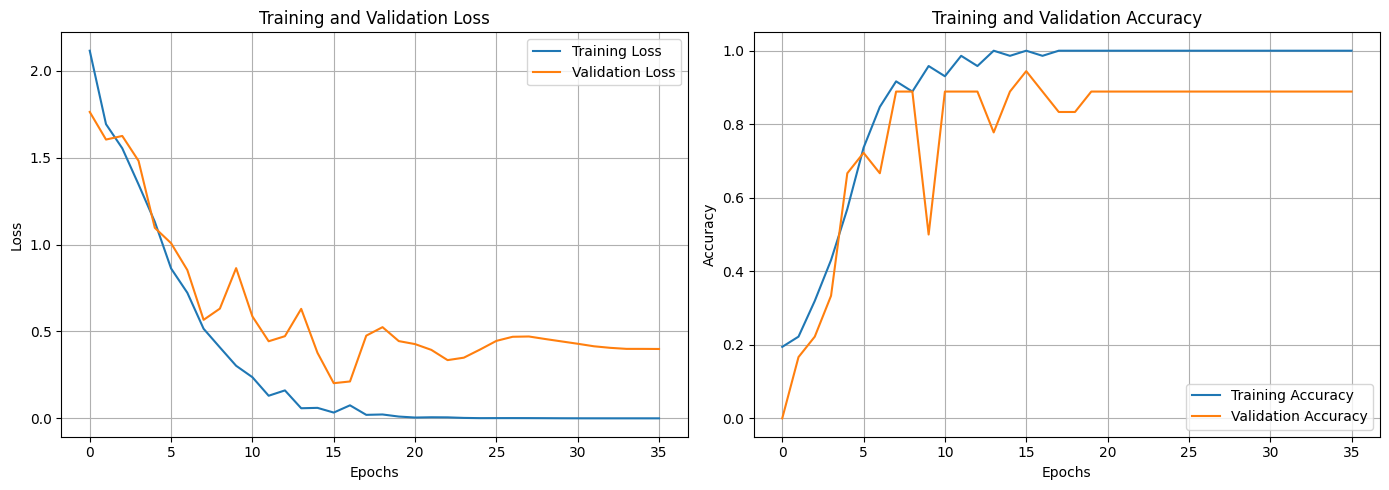

In [7]:
# TASK 4 - Compile and Train the Model

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")


# Define callbacks
# ModelCheckpoint saves the best model to Google Drive
# so it is not lost when the session restarts
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/AI and Machine Learning/best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# EarlyStopping stops training when model stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)


# Plot training and validation loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
# TASK 5 - Evaluate the Model

# Model evaluation measures the performance of the trained
# model on the test dataset which contains images the model
# has never seen during training.
# The best model saved during training is loaded from
# Google Drive before evaluation to ensure the best
# weights are used.

# Load the best saved model from Google Drive
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/AI and Machine Learning/best_model.h5'
)
print("Best model loaded successfully.")


# Recompile the loaded model before evaluation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model recompiled successfully.")


# Evaluate the model on the test dataset
# The test dataset contains images the model
# has never seen during training
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Best model loaded successfully.
Model recompiled successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6333 - loss: 0.7355

Test Loss:     0.7355
Test Accuracy: 0.6333
Test Accuracy: 63.33%


In [10]:
# TASK 6 - Save and Load the Model

save_path = '/content/drive/MyDrive/AI and Machine Learning/final_model.h5'

# Save the current model (the one already in memory from Task 5)
model.save(save_path)
print(f"Model saved to: {save_path}")

# Load it back
loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully.")

# Recompile (suppresses the compiled metrics warning)
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Re-evaluate to confirm it matches Task 5 results
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds, verbose=1)

print(f"\nLoaded Model - Test Loss:     {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_accuracy * 100:.2f}%")

Model saved to: /content/drive/MyDrive/AI and Machine Learning/final_model.h5
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6333 - loss: 0.7355

Loaded Model - Test Loss:     0.7355
Loaded Model - Test Accuracy: 63.33%


In [11]:
# TASK 7 - Predictions and Classification Report

# model.predict() generates probability distributions over all classes.
# np.argmax() converts each probability vector into the predicted class index.
# classification_report compares predictions to ground truth labels
# and reports per-class precision, recall and f1-score.

from sklearn.metrics import classification_report
import numpy as np

# Collect all true labels and predictions from the test dataset
all_true_labels  = []
all_predictions  = []

for images, labels in test_ds:
    # Get predicted probabilities for each batch
    preds = loaded_model.predict(images, verbose=0)

    # Convert probabilities to class indices
    predicted_labels = np.argmax(preds, axis=1)

    all_true_labels.extend(labels.numpy())
    all_predictions.extend(predicted_labels)

all_true_labels = np.array(all_true_labels)
all_predictions = np.array(all_predictions)

# Print the classification report
# class_names maps integer labels back to fruit names
print("Classification Report:\n")
print(classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names
))

Classification Report:

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.80      0.80      0.80         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.67      0.80      0.73         5
      tucuma       0.38      0.60      0.46         5

    accuracy                           0.63        30
   macro avg       0.68      0.63      0.64        30
weighted avg       0.68      0.63      0.64        30

